In [1]:
print("Coding after a long break!!")

Coding after a long break!!


#### Langchain v1

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq
from langchain.tools import tool
from pydantic.v1 import BaseModel as BaseModelV1
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

c:\Users\Krishna\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\utils\pydantic.py:41: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


In [3]:
@tool
def simpleadviser():
    """Provide advice for people experiencing one-sided love."""
    return "This is a simple tool that returns advice for dealing with one-sided love"

In [4]:
from langchain.agents import create_agent
agent  = create_agent(
    model = "groq:llama-3.1-8b-instant",
    # verbose = True,
    system_prompt = "You're a helpful and supportive AI assistant for the people who are in one side love",
    tools = [simpleadviser]
)

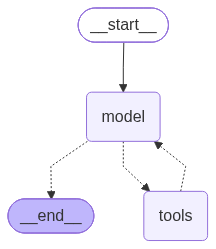

In [5]:
agent

In [6]:
res = agent.invoke({"input": "Help me to come out of the depression"})

In [7]:
res["messages"][-1].content

"However, it would be better to provide some context or specific information about the person's situation to get more tailored advice. For example, you could provide the person's age, the nature of their relationship (e.g., friend, coworker, romantic interest), and any specific challenges they're facing.\n\nIf you'd like, we can try to provide more general advice or guidance on how to approach one-sided love."

In [8]:
import langchain as lc
lc.__version__

'1.3.13'

In [9]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

google_api_key = os.getenv("GOOGLE_API_KEY")
if not google_api_key:
    raise ValueError("GOOGLE_API_KEY not found in environment variables. Please set it in your .env file or environment.")

os.environ["GOOGLE_API_KEY"] = google_api_key

In [10]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    "google_genai:gemini-3.5-flash"
)

response = model.invoke("How parrots talk?")
print(response.content)
print(response.text)

[{'type': 'text', 'text': 'Parrots are famous for their ability to talk, but how they do it is a fascinating mix of unique anatomy, high intelligence, and social behavior. \n\nUnlike humans, parrots do not have vocal cords, lips, or teeth. Here is how they manage to mimic human speech so perfectly.\n\n---\n\n### 1. The Anatomy: The Syrinx\nInstead of a larynx (vocal box) at the top of their windpipe like humans, birds have a vocal organ called a **syrinx** located deep in their chest, where the trachea splits into the lungs. \n\n* **Dual Control:** The syrinx is surrounded by strong muscles. Because it is located where the airway splits, parrots can control the left and right sides of the syrinx independently. This allows them to produce two different sounds at the same time, or seamlessly blend sounds.\n* **The Tongue:** Parrots have thick, muscular, and highly flexible tongues (similar to human tongues). By moving their tongue, changing the shape of their throat, and opening or closi

#### Streaming

In [12]:
for chunk in model.stream("Say hello in 10 different Indian Languages"):
    print(chunk.text, end="|", flush=True)

Here is how you say "Hello" in 10 different| Indian languages, along with their scripts and pronunciation:

1. **Hindi**
   * **Greeting:** नमस्ते (Namaste) or| नमस्कार (Namaskar)

2. **Tamil**
   * **Greeting:** வணக்கம் (Vanakkam)

3. **Bengali|**
   * **Greeting:** নমস্কার (Nomoshkar)

4. **Telugu**
   * **|Greeting:** నమస్కారం (Namaskaram)

5. **Marathi**
   * **Greeting:** नमस्कार (Namaskar)|

6. **Punjabi**
   * **Greeting:** ਸਤਿ ਸ੍ਰੀ ਅਕਾਲ (Sat| Sri Akal) 

7. **Gujarati**
   * **Greeting:** નમસ્તે (Namaste) or| નમસ્કાર (Namaskar)

8. **Kannada**
   * **Greeting:** ನಮಸ್ಕಾರ| (Namaskara)

9. **Malayalam**
   * **Greeting:** നമസ്കാരം (Namask|aram)

10. **Odia**
    * **Greeting:** ନମସ୍କାର (Namask|ara)|||

#### Batch
Batching is a collection of independent requests to a model can significantly improve performance and reduce costs as the processing can be done in parallel.

In [15]:
responses = model.batch([
    "Why Modi government is sucking in India?",
    "What is happening in Jantar mantar protest in Delhi",
    "Explain the theory of relativity in simple terms.",
],
    config={
        'max_concurrency':2
    }
)
for response in responses:
    print(response.content)
    print(response.text)

[{'type': 'text', 'text': 'The performance of the Narendra Modi-led government, which has been in power in India since 2014, is a subject of intense debate both within the country and internationally. While the administration has a large base of strong supporters who point to significant achievements, it also faces substantial criticism from political opponents, activists, and economists. \n\nTo understand the different perspectives, it is helpful to look at both the key criticisms directed at the government and the arguments made by its supporters.\n\n---\n\n### Key Criticisms of the Modi Government\n\nCritics and opponents argue that the government\'s policies and governance style have negatively impacted India in several key areas:\n\n1. **Economic Challenges and Unemployment:**\n   * **Unemployment:** Critics frequently point to high rates of youth unemployment and jobless growth as major failures. Despite overall GDP growth, job creation has not kept pace with the growing workforc